## **LIBRERÍAS**

In [ ]:
!pip install matplotlib

In [ ]:
# importamos todas las librerías necesarias para que aparezca correctament el gráfico

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy import stats
import numpy as np

from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler

from sqlalchemy import create_engine, select
from sqlalchemy import text
from sqlalchemy.orm import sessionmaker

import glob
import os

pd.set_option('display.max_rows',30)
pd.set_option('display.max_columns',None)

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

## **CONEXIÓN BBDD / Excel**

In [ ]:
# Configuración de la conexión a PostgreSQL
usuario = "avnadmin"
contrasena = "AVNS_Snql1CSp1zYrJCH6cXE"
servidor = "my-database-pg-my-data22.f.aivencloud.com"
puerto = "13676"
base_datos = "my_wyscout"

# Crea la cadena de conexión
conexion_str = f'postgresql+psycopg2://{usuario}:{contrasena}@{servidor}:{puerto}/{base_datos}'
engine = create_engine(conexion_str)

In [ ]:
# Cargar los datos desde un archivo Excel
#df_historico = '/content/drive/MyDrive/MIS_ANÁLISIS/Datos/datos_wyscout/FOCUS/Salida/s_Scout_Historico_Jugadores.xlsx'
#df_actual = '/content/drive/MyDrive/MIS_ANÁLISIS/Datos/datos_wyscout/FOCUS/Salida/s_Scout_TempActual_Jugadores.xlsx'
#df1 = pd.read_excel(df_historico)
#df2 = pd.read_excel(df_actual)

#Unir los dos df
#df = pd.concat([df1, df2], ignore_index=True)

In [ ]:
s_sql = text("""SELECT "Competición", "Temporada", "Posición Principal",	"Jugador", "Equipo", "Equipo durante el período seleccionado", "Posición específica",
	"Edad", "Valor de mercado (Transfermarkt)", "Vencimiento contrato", "Partidos jugados", "Minutos jugados", "Goles", "xG", "Asistencias", "xA", "Duelos/90",
	"Duelos ganados %", "País de nacimiento", "Pasaporte", "Pie", "Altura", "Peso", "En prestamo", "Acciones defensivas realizadas/90", "Duelos defensivos/90", "Duelos defensivos ganados %",
	"Duelos aéreos/90", "Duelos aéreos ganados %", "Entradas/90", "Acciones de ataque exitosas/90", "Asistencias/90", "Asistencias/90.1",
    "Ataque en profundidad/90", "Carreras en progresión/90", "Centros desde el último tercio/90", "Centros desde la banda derecha/90",
    "Centros/90",
	"Desmarques/90", "Duelos aéreos/90.1", "Duelos atacantes ganados %", "Duelos atacantes/90", "Faltas recibidas/90", "Faltas/90",
	"Goles (excepto los penaltis)", "Goles de cabeza/90", "Goles evitados", "Goles hechos %", "Goles recibidos/90", "Goles/90",
	 "Interceptaciones/90", "Jugadas claves/90", "Longitud media pases, m",
    "Longitud media pases largos, m", "Pais_Comp", 	"Paradas %", "Pases al área de penalti/90",
    "Pases cortos / medios /90", "Pases en el último tercio/90", "Pases hacia adelante/90", "Pases hacía atrás recibidos del arquero/90",
	"Pases hacía el área pequeña %", "Pases largos recibidos/90", "Pases largos/90", "Pases laterales/90", "Pases progresivos/90",
    "Pases recibidos /90", "Pases/90", "Penaltis a favor", "Penaltis realizados %", "Porterías imbatidas/90",
    "Posesión conquistada después de una interceptación", "Precisión centros %", "Precisión centros desde la banda derecha %",
    "Precisión centros desde la banda izquierda %", "Precisión pases %", "Precisión pases cortos / medios %",
	"Precisión pases en el último tercio %", "Precisión pases en profundidad %", "Precisión pases hacia adelante %",
    "Precision pases hacia atrás %",  "Precisión pases laterales %", "Precisión pases progresivos %", "Regates realizados %", "Regates/90",
    "Remates en contra", "Remates en contra/90", "Remates", "Remates/90",
	"Salidas/90", "Second assists/90", "Tarjetas amarillas", "Tarjetas rojas", "Tarjetas rojas/90", "Third assists/90",
    "Tiros a la portería %", "Tiros interceptados/90", "Tiros libres directos %", "Tiros libres directos/90", "Tiros libres/90",
    "Toques en el área de penalti/90", "xA/90",  "xG en contra", "xG en contra/90", "xG/90",
	"Goles, excepto los penaltis/90", "Posesión conquistada después de una entrada", "Aceleraciones/90", "Centros al área pequeña/90",
    "Centros desde la banda izquierda/90", "Córneres/90",
    "Fecha_Actualizacion",
    "Goles de cabeza", "Goles evitados/90", "Goles recibidos",
	"Pases en profundidad/90", "Pases hacia atrás/90", "Precisión desmarques %",
	"Precisión pases largos %", "Tarjetas amarillas/90"
from jugadores j
union
SELECT "Competición", "Temporada", "Posición Principal",	"Jugador", "Equipo", "Equipo durante el período seleccionado", "Posición específica",
	"Edad", "Valor de mercado (Transfermarkt)", "Vencimiento contrato", "Partidos jugados", "Minutos jugados", "Goles", "xG", "Asistencias", "xA", "Duelos/90",
	"Duelos ganados %", "País de nacimiento", "Pasaporte", "Pie", "Altura", "Peso", "En prestamo", "Acciones defensivas realizadas/90", "Duelos defensivos/90", "Duelos defensivos ganados %",
	"Duelos aéreos/90", "Duelos aéreos ganados %", "Entradas/90", "Acciones de ataque exitosas/90", "Asistencias/90", "Asistencias/90.1",
    "Ataque en profundidad/90", "Carreras en progresión/90", "Centros desde el último tercio/90", "Centros desde la banda derecha/90",
    "Centros/90",
	"Desmarques/90", "Duelos aéreos/90.1", "Duelos atacantes ganados %", "Duelos atacantes/90", "Faltas recibidas/90", "Faltas/90",
	"Goles (excepto los penaltis)", "Goles de cabeza/90", "Goles evitados", "Goles hechos %", "Goles recibidos/90", "Goles/90",
	 "Interceptaciones/90", "Jugadas claves/90", "Longitud media pases, m",
    "Longitud media pases largos, m", "Pais_Comp", 	"Paradas %", "Pases al área de penalti/90",
    "Pases cortos / medios /90", "Pases en el último tercio/90", "Pases hacia adelante/90", "Pases hacía atrás recibidos del arquero/90",
	"Pases hacía el área pequeña %", "Pases largos recibidos/90", "Pases largos/90", "Pases laterales/90", "Pases progresivos/90",
    "Pases recibidos /90", "Pases/90", "Penaltis a favor", "Penaltis realizados %", "Porterías imbatidas/90",
    "Posesión conquistada después de una interceptación", "Precisión centros %", "Precisión centros desde la banda derecha %",
    "Precisión centros desde la banda izquierda %", "Precisión pases %", "Precisión pases cortos / medios %",
	"Precisión pases en el último tercio %", "Precisión pases en profundidad %", "Precisión pases hacia adelante %",
    "Precision pases hacia atrás %",  "Precisión pases laterales %", "Precisión pases progresivos %", "Regates realizados %", "Regates/90",
    "Remates en contra", "Remates en contra/90", "Remates", "Remates/90",
	"Salidas/90", "Second assists/90", "Tarjetas amarillas", "Tarjetas rojas", "Tarjetas rojas/90", "Third assists/90",
    "Tiros a la portería %", "Tiros interceptados/90", "Tiros libres directos %", "Tiros libres directos/90", "Tiros libres/90",
    "Toques en el área de penalti/90", "xA/90",  "xG en contra", "xG en contra/90", "xG/90",
	"Goles, excepto los penaltis/90", "Posesión conquistada después de una entrada", "Aceleraciones/90", "Centros al área pequeña/90",
    "Centros desde la banda izquierda/90", "Córneres/90",
    "Fecha_Actualizacion",
    "Goles de cabeza", "Goles evitados/90", "Goles recibidos",
	"Pases en profundidad/90", "Pases hacia atrás/90", "Precisión desmarques %",
	"Precisión pases largos %", "Tarjetas amarillas/90"
from hist_jugadores hj
;""")

In [ ]:
# Ejecutar la consulta SQL
df = pd.read_sql(s_sql, conexion_str)  # Cargar resultados en un DataFrame


In [ ]:
df_allplayers = df.copy()
df_allplayers = df_allplayers.drop_duplicates()
#Eliminar filas promedio
filas_a_eliminar = df_allplayers['Jugador'].str.startswith('Promedio')

# 3. Filtra el DataFrame para quedarse con las filas que NO cumplen la condición
#    (es decir, aquellas donde la máscara es False)
df_allplayers = df_allplayers[~filas_a_eliminar]

In [ ]:
# comprobamos si se han descargado bien todos los datos de los jugadores
df_allplayers.head(5)

,Competición,Temporada,Posición Principal,Jugador,Equipo,Equipo durante el período seleccionado,Posición específica,Edad,Valor de mercado (Transfermarkt),Vencimiento contrato,Partidos jugados,Minutos jugados,Goles,xG,Asistencias,xA,Duelos/90,Duelos ganados %,País de nacimiento,Pasaporte,Pie,Altura,Peso,En prestamo,Acciones defensivas realizadas/90,Duelos defensivos/90,Duelos defensivos ganados %,Duelos aéreos/90,Duelos aéreos ganados %,Entradas/90,Acciones de ataque exitosas/90,Asistencias/90,Asistencias/90.1,Ataque en profundidad/90,Carreras en progresión/90,Centros desde el último tercio/90,Centros desde la banda derecha/90,Centros/90,Desmarques/90,Duelos aéreos/90.1,Duelos atacantes ganados %,Duelos atacantes/90,Faltas recibidas/90,Faltas/90,Goles (excepto los penaltis),Goles de cabeza/90,Goles evitados,Goles hechos %,Goles recibidos/90,Goles/90,Interceptaciones/90,Jugadas claves/90,"Longitud media pases, m","Longitud media pases largos, m",Pais_Comp,Paradas %,Pases al área de penalti/90,Pases cortos / medios /90,Pases en el último tercio/90,Pases hacia adelante/90,Pases hacía atrás recibidos del arquero/90,Pases hacía el área pequeña %,Pases largos recibidos/90,Pases largos/90,Pases laterales/90,Pases progresivos/90,Pases recibidos /90,Pases/90,Penaltis a favor,Penaltis realizados %,Porterías imbatidas/90,Posesión conquistada después de una interceptación,Precisión centros %,Precisión centros desde la banda derecha %,Precisión centros desde la banda izquierda %,Precisión pases %,Precisión pases cortos / medios %,Precisión pases en el último tercio %,Precisión pases en profundidad %,Precisión pases hacia adelante %,Precision pases hacia atrás %,Precisión pases laterales %,Precisión pases progresivos %,Regates realizados %,Regates/90,Remates en contra,Remates en contra/90,Remates,Remates/90,Salidas/90,Second assists/90,Tarjetas amarillas,Tarjetas rojas,Tarjetas rojas/90,Third assists/90,Tiros a la portería %,Tiros interceptados/90,Tiros libres directos %,Tiros libres directos/90,Tiros libres/90,Toques en el área de penalti/90,xA/90,xG en contra,xG en contra/90,xG/90,"Goles, excepto los penaltis/90",Posesión conquistada después de una entrada,Aceleraciones/90,Centros al área pequeña/90,Centros desde la banda izquierda/90,Córneres/90,Fecha_Actualizacion,Goles de cabeza,Goles evitados/90,Goles recibidos,Pases en profundidad/90,Pases hacia atrás/90,Precisión desmarques %,Precisión pases largos %,Tarjetas amarillas/90
0,1DIVI,2018-2019,Central,A. Ba,Tondela,Rayo Vallecano,"RCB, CB",33,100000,2024-06-30,26,2241,1,1.11,0,0.17,14.22,60.73,Senegal,Senegal,derecho,197,79,no,11.77,5.86,68.49,4.34,59.26,0.60,0.32,0.0,0.08,0.16,0.16,0.04,0.12,0.12,0.00,NaN,54.29,1.41,0.60,0.88,1,0.04,NaN,12.500,NaN,0.04,7.15,0.00,22.35,39.61,ESP,0.0,0.28,34.70,3.61,16.91,2.69,42.86,0.32,5.58,17.31,8.51,24.98,40.40,0,0.0,0,10.02,33.33,33.33,0.0,84.99,90.97,60.00,0.00,72.68,98.65,94.43,61.32,60.00,0.20,0,NaN,8,0.32,NaN,0.00,4,2,0.08,0.0,50.00,0.56,0.0,0.00,0.00,0.44,0.01,0.0,0.0,0.04,0.04,0.84,0.00,0.0,0.0,0.0,2025-05-23 12:56:25.752890,1,NaN,0,0.08,2.97,0.0,48.92,0.16
1,1DIVI,2018-2019,Central,Adrián Diéguez,Jagiellonia Białystok,Huesca,"CB, LCB",28,1000000,2025-06-30,9,815,0,0.28,0,0.00,15.24,58.70,Spain,Spain,izquierdo,188,78,no,11.60,7.84,67.61,3.09,57.14,1.21,0.77,0.0,0.00,0.11,0.22,0.00,0.00,0.00,0.22,NaN,71.43,1.55,0.77,0.77,0,0.00,NaN,0.000,NaN,0.00,5.08,0.00,20.88,36.08,ESP,0.0,0.44,17.89,2.65,12.26,0.44,0.00,0.00,4.20,6.52,4.53,10.82,22.09,0,0.0,0,6.48,0.00,0.00,0.0,75.50,85.80,33.33,0.00,69.37,85.71,86.44,53.66,75.00,0.88,0,NaN,1,0.11,NaN,0.00,3,0,0.00,0.0,100.00,0.33,0.0,0.00,0.00,0.22,0.00,0.0,0.0,0.03,0.00,1.55,0.11,0.0,0.0,0.0,2025-05-23 12:56:25.752890,0,NaN,0,0.33,0.77,0.0,31.58,0.33
2,1DIVI,2018-2019,Central,Alcalá,Cartagena,Girona,RCB,35,300000,2026-06-30,25,2001,1,0.69,0,0.41,14.93,60.24,Spain,Spain,derecho,196,93,no,10.03,5.58,63.71,6.30,62.14,0.54,0.49,0.0,0.13,0.40,0.54,0.00,0.18,0.18,0.00,NaN,55.00,0.90,0.54,0.99,1,0.04,NaN,10.000,N

## **MÉTRICAS**

In [ ]:
fase_defensiva = ['Acciones defensivas realizadas/90','Duelos aéreos/90',
                'Duelos aéreos ganados %','Duelos defensivos ganados %','Duelos defensivos/90','Entradas/90',
                'Faltas/90','Interceptaciones/90','Posesión conquistada después de una entrada',
                'Posesión conquistada después de una interceptación','Tarjetas amarillas','Tarjetas amarillas/90',
                'Tarjetas rojas','Tarjetas rojas/90','Tiros interceptados/90']

ABP = ['Córneres/90','Penaltis a favor','Penaltis realizados %','Tiros libres directos %',
       'Tiros libres directos/90','Tiros libres/90']

acc_ofensivas = ['Acciones de ataque exitosas/90','Aceleraciones/90','Asistencias','Asistencias/90',
                'Carreras en progresión/90','Centros al área pequeña/90','Centros desde la banda derecha/90',
                'Centros desde la banda izquierda/90','Centros/90','Duelos atacantes ganados %',
                'Duelos atacantes/90','Faltas recibidas/90','Goles','Goles (excepto los penaltis)',
                'Goles de cabeza','Goles de cabeza/90','Goles hechos %','Goles, excepto los penaltis/90',
                'Goles/90','Pases largos recibidos/90','Pases recibidos /90','Precisión centros %',
                'Precisión centros desde la banda derecha %','Precisión centros desde la banda izquierda %',
                'Regates realizados %','Regates/90','Remates','Remates/90','Tiros a la portería %',
                'Toques en el área de penalti/90','xG','xG/90']

fisica = ['Total Distance per 90','Running Distance per 90 (15-20 km/h)','HSR Distance per 90 (20-25 km/h)',
          'Sprinting Distance per 90 (+25 km/h)','HI Distance per 90 (+20 km/h)','Meter/Min','Max Speed (km/h)',
          'Count Medium Acceleration per 90 (1.5 m/s² to 3 m/s²)','Count High Acceleration per 90 (+3 m/s²)',
          'Count Medium Deceleration per 90 (-1.5 m/s² to -3 m/s²)','Count High Deceleration per 90 (-3 m/s²)',
          'Count HSR per 90 (20-25 km/h)','Count Sprint per 90 (+25 km/h)','Count HI per 90 (+20 km/h)']

fugadas_clave = ['Asistencias','Asistencias/90',
                'Ataque en profundidad/90','Centros desde el último tercio/90','Desmarques/90',
                'Jugadas claves/90','Pases al área de penalti/90','Pases en el último tercio/90',
                'Pases en profundidad/90','Pases hacía el área pequeña %','Pases progresivos/90',
                'Precisión desmarques %','Precisión pases en el último tercio %',
                'Precisión pases en profundidad %','Precisión pases progresivos %','Second assists/90',
                'Third assists/90','xA','xA/90']

organizacion = ['Longitud media pases largos, m','Longitud media pases, m','Pases cortos / medios /90',
                'Pases hacia adelante/90','Pases hacia atrás/90','Pases largos/90','Pases laterales/90',
                'Pases/90','Precisión pases %','Precisión pases cortos / medios %',
                'Precisión pases hacia adelante %','Precision pases hacia atrás %','Precisión pases largos %',
                'Precisión pases laterales %']

portero2 = ['Acciones defensivas realizadas/90','Duelos aéreos/90',
          'Duelos aéreos ganados %','Duelos defensivos ganados %','Duelos ganados %','Goles evitados',
          'Goles evitados/90','Goles recibidos','Goles recibidos/90','Longitud media pases largos, m',
          'Longitud media pases, m','Paradas %','Pases hacia adelante/90',
          'Pases hacía atrás recibidos del arquero/90','Pases hacia atrás/90','Pases largos/90',
          'Pases laterales/90','Pases/90','Porterías imbatidas en los 90','Precisión pases %',
          'Precisión pases cortos / medios %','Precisión pases hacia adelante %',
          'Precision pases hacia atrás %','Precisión pases largos %','Precisión pases laterales %',
          'Remates en contra','Remates en contra/90','Salidas/90','xG en contra','xG en contra/90']

portero = ['Goles evitados',
          'Goles evitados/90','Goles recibidos','Goles recibidos/90','Paradas %',
          'Porterías imbatidas/90','Remates en contra','Remates en contra/90',
          'Salidas/90','xG en contra','xG en contra/90']

todas = ['Acciones de ataque exitosas/90','Acciones defensivas realizadas/90','Aceleraciones/90','Asistencias','Asistencias/90',
        'Ataque en profundidad/90','Carreras en progresión/90','Centros al área pequeña/90','Centros desde el último tercio/90',
        'Centros desde la banda derecha/90','Centros desde la banda izquierda/90','Centros/90','Córneres/90','Desmarques/90',
        'Duelos aéreos/90',
        'Duelos aéreos ganados %','Duelos atacantes ganados %','Duelos atacantes/90','Duelos defensivos ganados %','Duelos defensivos/90',
        'Duelos ganados %','Duelos/90','Entradas/90','Faltas recibidas/90','Faltas/90','Goles','Goles (excepto los penaltis)',
        'Goles de cabeza','Goles de cabeza/90','Goles hechos %','Goles, excepto los penaltis/90','Goles/90','Interceptaciones/90','Jugadas claves/90',
        'Longitud media pases largos, m','Longitud media pases, m','Paradas %','Pases al área de penalti/90','Pases cortos / medios /90',
        'Pases en el último tercio/90','Pases en profundidad/90','Pases hacia adelante/90','Pases hacía atrás recibidos del arquero/90',
        'Pases hacia atrás/90','Pases hacía el área pequeña %','Pases largos recibidos/90','Pases largos/90','Pases laterales/90',
        'Pases progresivos/90','Pases recibidos /90','Pases/90','Penaltis a favor','Penaltis realizados %',
        'Posesión conquistada después de una entrada',
        'Posesión conquistada después de una interceptación','Precisión centros %',
        'Precisión centros desde la banda derecha %','Precisión centros desde la banda izquierda %',
        'Precisión desmarques %','Precisión pases %','Precisión pases cortos / medios %',
        'Precisión pases en el último tercio %','Precisión pases en profundidad %',
        'Precisión pases hacia adelante %','Precision pases hacia atrás %','Precisión pases largos %',
        'Precisión pases laterales %','Precisión pases progresivos %','Regates realizados %',
        'Regates/90','Remates','Remates/90',
        'Second assists/90','Tarjetas amarillas','Tarjetas amarillas/90','Tarjetas rojas','Tarjetas rojas/90',
        'Third assists/90','Tiros a la portería %','Tiros interceptados/90','Tiros libres directos %',
        'Tiros libres directos/90','Tiros libres/90','Toques en el área de penalti/90',
        'xA','xA/90','xG','xG/90']

central = [
        'Duelos defensivos/90',
        'Duelos defensivos ganados %',
        'Interceptaciones/90',
        'Pases progresivos/90',
        'Duelos aéreos ganados %']

# Definir métricas clave por posición ===
# metricas_por_posicion = {
#     "Portero": {
#         "Goles recibidos/90": 0.25,
#         "Paradas %": 0.25,
#         "xG en contra/90": 0.20,
#         "Goles evitados/90": 0.20,
#         "Porterías imbatidas en los 90": 0.10
#     },
#     "Central": {
#         "Duelos defensivos/90": 0.25,
#         "Duelos defensivos ganados %": 0.25,
#         "Intercepciones/90": 0.20,
#         "Pases progresivos/90": 0.15,
#         "Duelos aéreos ganados %": 0.15
#     },
#     "Lateral": {
#         "Entradas/90": 0.20, #lateral
#         "Interceptaciones/90": 0.15, #lateral
#         "Centros/90": 0.20, #comun
#         "Precisión centros %": 0.15, #comun
#         "Carreras en progresión/90": 0.15, #comun
#         "Regates/90": 0.15 #comun
#         #,"Acciones de ataque exitosas/90": 0.20 #carrilero
#      },
#     "centrocampista": {
#         "Pases/90": 0.25,
#         "Precisión pases %": 0.25,
#         "Interceptaciones/90": 0.20,
#         "Duelos defensivos ganados %": 0.15,
#         "Recuperaciones/90": 0.15
#         #,"Goles/90": 0.25, #media punta
#         #,"Asistencias/90": 0.20, #media punta
#         #,"xA/90": 0.20, #media punta
#         #,"Regates/90": 0.15, #media punta
#         #,"Key passes/90": 0.20 #media punta
#     },
#     #"medio organizador": {
#     #    "Pases progresivos/90": 0.25,
#     #    "Pases en el último tercio/90": 0.20,
#     #    "Asistencias/90": 0.20,
#     #    "xA/90": 0.20,
#     #    "Key passes/90": 0.15
#     #},
#     "Extremo": {
#         "Regates/90": 0.25,
#         "Regates realizados %": 0.15,
#         "Carreras en progresión/90": 0.20,
#         "Centros/90": 0.15,
#         "Precisión centros %": 0.10,
#         "Goles/90": 0.15
#     },
#     "Delantero": {
#         "Goles/90": 0.30,
#         "xG/90": 0.25,
#         "Tiros a portería %": 0.15,
#         "Duelos ofensivos ganados %": 0.15,
#         "Toques en el área de penalti/90": 0.15
#     }
# }


## **BÚSQUEDA DEL JUGADOR MODELO**

In [ ]:
#Buscar nombre del jugador modelo
df_allplayers[df_allplayers.Jugador.str.contains('Joan G')].head(5)



,Competición,Temporada,Posición Principal,Jugador,Equipo,Equipo durante el período seleccionado,Posición específica,Edad,Valor de mercado (Transfermarkt),Vencimiento contrato,Partidos jugados,Minutos jugados,Goles,xG,Asistencias,xA,Duelos/90,Duelos ganados %,País de nacimiento,Pasaporte,Pie,Altura,Peso,En prestamo,Acciones defensivas realizadas/90,Duelos defensivos/90,Duelos defensivos ganados %,Duelos aéreos/90,Duelos aéreos ganados %,Entradas/90,Acciones de ataque exitosas/90,Asistencias/90,Asistencias/90.1,Ataque en profundidad/90,Carreras en progresión/90,Centros desde el último tercio/90,Centros desde la banda derecha/90,Centros/90,Desmarques/90,Duelos aéreos/90.1,Duelos atacantes ganados %,Duelos atacantes/90,Faltas recibidas/90,Faltas/90,Goles (excepto los penaltis),Goles de cabeza/90,Goles evitados,Goles hechos %,Goles recibidos/90,Goles/90,Interceptaciones/90,Jugadas claves/90,"Longitud media pases, m","Longitud media pases largos, m",Pais_Comp,Paradas %,Pases al área de penalti/90,Pases cortos / medios /90,Pases en el último tercio/90,Pases hacia adelante/90,Pases hacía atrás recibidos del arquero/90,Pases hacía el área pequeña %,Pases largos recibidos/90,Pases largos/90,Pases laterales/90,Pases progresivos/90,Pases recibidos /90,Pases/90,Penaltis a favor,Penaltis realizados %,Porterías imbatidas/90,Posesión conquistada después de una interceptación,Precisión centros %,Precisión centros desde la banda derecha %,Precisión centros desde la banda izquierda %,Precisión pases %,Precisión pases cortos / medios %,Precisión pases en el último tercio %,Precisión pases en profundidad %,Precisión pases hacia adelante %,Precision pases hacia atrás %,Precisión pases laterales %,Precisión pases progresivos %,Regates realizados %,Regates/90,Remates en contra,Remates en contra/90,Remates,Remates/90,Salidas/90,Second assists/90,Tarjetas amarillas,Tarjetas rojas,Tarjetas rojas/90,Third assists/90,Tiros a la portería %,Tiros interceptados/90,Tiros libres directos %,Tiros libres directos/90,Tiros libres/90,Toques en el área de penalti/90,xA/90,xG en contra,xG en contra/90,xG/90,"Goles, excepto los penaltis/90",Posesión conquistada después de una entrada,Aceleraciones/90,Centros al área pequeña/90,Centros desde la banda izquierda/90,Córneres/90,Fecha_Actualizacion,Goles de cabeza,Goles evitados/90,Goles recibidos,Pases en profundidad/90,Pases hacia atrás/90,Precisión desmarques %,Precisión pases largos %,Tarjetas amarillas/90
2856,1DIVI,2021-2022,Portero,Joan García,Espanyol,Espanyol,GK,23,800000,2028-06-30,2,122,0,0.00,0,0.00,0.00,0.00,Spain,Spain,derecho,181,77,no,3.69,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,0.00,-1.43,0.000,2.21,0.00,3.69,0.00,31.33,44.26,ESP,0.00,0.00,14.75,2.21,11.07,0.00,0.00,0.00,5.16,6.64,2.95,9.59,19.92,0,0.0,0,4.69,0.00,0.00,0.00,96.30,100.00,66.67,0.00,93.33,0.00,100.00,100.00,0.00,0.00,3,2.21,0,0.00,1.48,0.0,0,0,0.0,0.0,0.00,0.0,NaN,NaN,NaN,0.00,0.00,1.57,1.16,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2025-05-23 12:56:25.752890,0,-1.055,3,0.00,0.00,0.00,85.71,0.00
3653,1DIVI,2022-2023,Portero,Joan García,Espanyol,Espanyol,GK,23,800000,2028-06-30,1,103,0,0.00,0,0.00,0.00,0.00,Spain,Spain,derecho,181,77,no,0.87,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,0.00,-1.16,0.000,2.62,0.00,0.87,0.00,24.01,48.15,ESP,25.00,0.00,17.48,0.00,16.60,0.00,0.00,1.75,4.37,5.24,2.62,11.36,21.84,0,0.0,0,2.00,0.00,0.00,0.00,96.00,100.00,0.00,0.00,94.74,0.00,100.00,66.67,0.00,0.00,4,3.50,0,0.00,0.87,0.0,0,0,0.0,0.0,0.00,0.0,NaN,NaN,NaN,0.00,0.00,1.84,1.61,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2025-05-23 12:56:25.752890,0,-1.014,3,0.00,0.00,0.00,80.00,0.00
5258,1DIVI,2024-2025,Portero,Joan García,Espanyol,Espanyol,GK,24,800000,2028-06-30,38,3789,0,0.19,0,0.00,0.90,86.84,Spain,Spain,derecho,191,77,no,2.02,0.05,50.00,0.74,90.32,0.02,0.02,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.74,100.00,0.02,0.14,0.00,0,0.00,2.52,0.000,1.21,0.00,1.97,0.

## **FILTROS DE BÚSQUEDA**

In [68]:
#FILTROS
stats_cols = portero
jugador_ref = "Joan García"
top_listado = 10

compe = '1DIVI'
Temp = '2024-2025'
Pos_ppal = 'Portero'
#Pos_esp1 = 'LDMF'
#Pos_esp2 = 'LCMF'
#Pos_esp3 = 'RCMF'
min_jugados = 1000
#Altura_ini = 170
#Altura_fin = 195
Edad_ini = 18
Edad_fin = 32

if compe == "1DIVI":
  liga = "1ª División"
elif compe == "2DIVI":
  liga = "2ª División"
elif compe == "1RFEF":
  liga = "1ª RFEF"
elif compe == "2RFEF":
  liga = "2ª RFEF"

In [69]:
df_filt = df_allplayers[(df_allplayers['Temporada'] == Temp) &
                             (df_allplayers['Posición Principal'] == Pos_ppal) &
                             (df_allplayers['Minutos jugados'] >= min_jugados) &
                             (df_allplayers['Competición'] == compe)
                             #((df_similares['Altura'].between(Altura_ini, Altura_fin)) | (df_similares['Altura'] == 0)) &
                             #(df_similares['Edad'].between(Edad_ini, Edad_fin))
                             #((df_similares['Posición específica'].str.contains(Pos_esp1)) |
                             # (df_similares['Posición específica'].str.contains(Pos_esp2))
                              #| (df_similares['Posición específica'].str.contains(Pos_esp3))
                             # )
                            ]

In [ ]:
#df_filt["Jugador_Equipo"] = df_filt["Jugador"] + " (" + df_filt["Equipo durante el período seleccionado"] + ")"
#df_filt.head()

## **SKLEARN CDIST COSINE**

In [70]:
# -------------------------------
# 3. PREPARAR MATRIZ DE CARACTERÍSTICAS
# -------------------------------
# Eliminamos jugadores con datos faltantes en estas métricas: jugadores sin datos o con datos incorrectos

df_stats = df_filt[["Jugador"] + stats_cols].dropna().reset_index(drop=True)

X = df_stats[stats_cols].astype(float)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------------
# 4. SELECCIÓN DE JUGADOR DE REFERENCIA PARA COMPARAR
# -------------------------------
# Cambia el nombre en rojo del jugador por el que quieras: debe ser el nombre exacto que aparece en FBREF

#jugador_ref = "Robin Le Normand"

if jugador_ref not in df_stats["Jugador"].values:
    raise ValueError(f"'{jugador_ref}' no está en el DataFrame filtrado.")

idx_ref = df_stats[df_stats["Jugador"] == jugador_ref].index[0]
ref_vector = X_scaled[idx_ref].reshape(1, -1)

# -------------------------------
# 5. CÁLCULO DE SIMILITUD / DISTANCIA COSINE
# -------------------------------
# La distancia euclidiana es una forma de medir qué tan parecidos son dos jugadores comparando sus estadísticas
# como si fueran puntos en un espacio, igual que medir con una regla la distancia entre dos lugares en un mapa.
distancias = cdist(ref_vector, X_scaled, metric='cosine').flatten() #metric='euclidean'


# -------------------------------
# 6. MOSTRAMOS RESULTADOS
# -------------------------------
df_stats["distancia"] = distancias
df_resultado = df_stats.sort_values("distancia").reset_index(drop=True)

# Mostramos los 5 jugadores más similares (el primero será él propio jugador comparado, con distancia 0)
df_resultado[["Jugador"] + stats_cols + ["distancia"]].head(top_listado+1)


,Jugador,Goles evitados,Goles evitados/90,Goles recibidos,Goles recibidos/90,Paradas %,Porterías imbatidas/90,Remates en contra,Remates en contra/90,Salidas/90,xG en contra,xG en contra/90,distancia
0,Joan García,2.52,0.060,51,1.21,74.11,8,197,4.68,2.21,53.52,1.27,0.000000
1,Sergio Herrera,0.91,0.022,52,1.27,71.74,8,184,4.50,1.22,52.91,1.29,0.203130
2,M. Dmitrović,8.92,0.253,49,1.39,68.99,10,158,4.48,2.18,57.92,1.64,0.237083
3,A. Batalla,7.01,0.198,39,1.10,73.83,8,149,4.22,1.47,46.01,1.30,0.305570
4,Antonio Sivera,1.20,0.035,39,1.13,67.77,8,121,3.50,1.65,40.20,1.16,0.596502
5,J. Cillessen,0.77,0.027,42,1.46,68.66,3,134,4.66,0.90,42.77,1.49,0.709889
6,K. Hein,-12.55,-0.367,68,1.99,59.28,5,167,4.89,1.52,55.45,1.62,0.776414
7,G. Mamardashvili,-5.18,-0.138,48,1.28,66.90,8,145,3.87,1.28,42.82,1.14,0.839816
8,P. Gazzaniga,-4.58,-0.118,51,1.31,65.31,8,147,3.78,1.03,46.42,1.19,0.927470
9,Luiz Júnior,-0.10,-0.006,18,1.00,75.00,5,72,4.01,2.06,17.90,1.00,1.066053


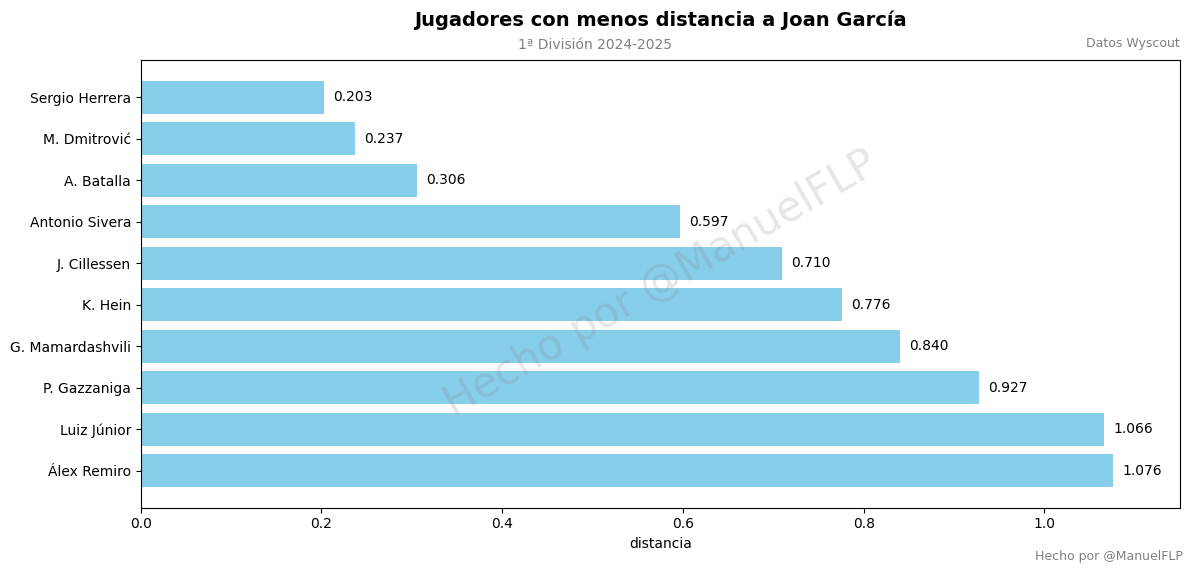

In [73]:
# Quitamos al propio jugador de referencia para ver el gráfico correctamente
# recuerda cambiar el nombre en rojo del jugador por el del que estés haciendo el análisis

df_resultado_filtrado = df_resultado[df_resultado["Jugador"] != jugador_ref].copy()

# Recalculamos la similitud para que no haya ningún error
#df_resultado_filtrado["distancia"] = 1 / (1 + df_resultado_filtrado["distancia"])

# Tomamos los más similares (ya sin el jugador original)
top_similares = df_resultado_filtrado[["Jugador", "distancia"]].head(top_listado)
#top_similares = top_similares.iloc[::-1]  # Para que el más similar quede arriba

#ordenamos
top_similares = top_similares.sort_values("distancia", ascending=False).head(top_listado)

# Generamos el gráfico

plt.figure(figsize=(12, 6))
bars = plt.barh(top_similares["Jugador"], top_similares["distancia"], color='skyblue')
plt.xlabel("distancia") # el jugador más similar estará más cerca de 1 que de 0

plt.title("Jugadores con menos distancia a " + jugador_ref, fontsize=14, weight='bold', pad=25)
plt.xlim(0, 1.15)

# Subtítulo debajo del título (pero arriba del gráfico)
plt.suptitle(
    liga + " " + Temp,
    fontsize=10,
    color="gray",
    y=0.88  # controlas la posición vertical del subtítulo
  )

# Texto en la esquina superior derecha (datos)
plt.text(
  1.0,
  1.023,
  "Datos Wyscout",
  ha="right", va="bottom", transform=plt.gca().transAxes, fontsize=9, color="gray"
)

#FIRMA
plt.figtext(0.99, 0.01, "Hecho por @ManuelFLP", ha="right", fontsize=9, color="gray")
#marca de agua
plt.text(0.5, 0.5, "Hecho por @ManuelFLP",
    transform=plt.gca().transAxes, fontsize=30, color="gray",
    alpha=0.2, ha="center", va="center", rotation=30)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2,
             f'{width:.3f}', va='center')

plt.tight_layout()
plt.show()
